## Classification Exercise: predict expected income based on individuals information

### Overview:
Use census data to analyze income levels and cluster individuals based on demographics and employment. The data includes the following columns:

| Column Name      | Description                                                                             |
| ---------------- | --------------------------------------------------------------------------------------- |
| `age`            | Age of the individual.                                                                  |
| `workclass`      | Type of employment (e.g., Private, Self-emp, Government).                               |
| `fnlwgt`         | Final weight — a demographic weight from the census (can often be ignored in modeling). |
| `education`      | Highest level of education attained (e.g., Bachelors, HS-grad).                         |
| `education-num`  | Numeric representation of education (e.g., 13 = Bachelors).                             |
| `marital-status` | Marital status (e.g., Never-married, Divorced).                                         |
| `occupation`     | Type of job (e.g., Tech-support, Craft-repair).                                         |
| `relationship`   | Relationship status (e.g., Husband, Not-in-family).                                     |
| `race`           | Race of the individual (e.g., White, Black).                                            |
| `sex`            | Sex of the individual.                                                                  |
| `capital-gain`   | Income from capital gains (e.g., selling stocks).                                       |
| `capital-loss`   | Losses from capital investments.                                                        |
| `hours-per-week` | Number of hours worked per week.                                                        |
| `native-country` | Country of origin (e.g., United                                                         |


### Goal:

Predict income level using Decision Tree and Random Forest

Understand feature importance and impact of model parameters

### Approach:

Preprocessing: Clean data, reduce categorical cardinality, encode, scale, split.

Modeling: Fit Decision Tree and Random Forest; test different depths and compare results.

Interpretation: Analyze feature importances.

<a id="1"></a> <br>
### 1. Import the basic packages and set the random seed

In [143]:
#  Random Forest on Adult Income Dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer


from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [116]:
# to ensure reproducibility
np.random.seed(42)
random_state = 42

### 2. Load and Preview the Data

In [117]:
# Load the dataset
adult = fetch_openml(name='adult', version=2, as_frame=True)
data = adult.frame.copy()

In [118]:
data.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In [119]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             48842 non-null  int64   
 1   workclass       46043 non-null  category
 2   fnlwgt          48842 non-null  int64   
 3   education       48842 non-null  category
 4   education-num   48842 non-null  int64   
 5   marital-status  48842 non-null  category
 6   occupation      46033 non-null  category
 7   relationship    48842 non-null  category
 8   race            48842 non-null  category
 9   sex             48842 non-null  category
 10  capital-gain    48842 non-null  int64   
 11  capital-loss    48842 non-null  int64   
 12  hours-per-week  48842 non-null  int64   
 13  native-country  47985 non-null  category
 14  class           48842 non-null  category
dtypes: category(9), int64(6)
memory usage: 2.7 MB


In [121]:
# Identify categorical and numerical columns
categorical_cols = data.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = data.select_dtypes(include=['int64', 'float64']).columns.tolist()

In [122]:
# print the cardinality of each categorical variable
for col in categorical_cols:
    print("{}: {} ".format(col, data[col].unique()))

workclass: ['Private', 'Local-gov', 'Self-emp-not-inc', 'Federal-gov', 'State-gov', 'Self-emp-inc', 'Without-pay']
Categories (8, object): ['Federal-gov', 'Local-gov', 'Never-worked', 'Private', 'Self-emp-inc', 'Self-emp-not-inc', 'State-gov', 'Without-pay'] 
education: ['11th', 'HS-grad', 'Assoc-acdm', 'Some-college', '10th', ..., '9th', 'Doctorate', '12th', '1st-4th', 'Preschool']
Length: 16
Categories (16, object): ['10th', '11th', '12th', '1st-4th', ..., 'Masters', 'Preschool', 'Prof-school', 'Some-college'] 
marital-status: ['Never-married', 'Married-civ-spouse', 'Widowed', 'Separated', 'Divorced', 'Married-spouse-absent', 'Married-AF-spouse']
Categories (7, object): ['Divorced', 'Married-AF-spouse', 'Married-civ-spouse', 'Married-spouse-absent', 'Never-married', 'Separated', 'Widowed'] 
occupation: ['Machine-op-inspct', 'Farming-fishing', 'Protective-serv', 'Other-service', 'Prof-specialty', ..., 'Sales', 'Priv-house-serv', 'Transport-moving', 'Handlers-cleaners', 'Armed-Forces']

### 3. cleaning of the data

In [144]:
# Drop rows with missing values
data.dropna(inplace=True)

In [147]:
# clean the marital-status to reduce the cardinality
#  the following dictionary is now part of the modeling and should be saved for future transformation during inference and test phases
marital_map = {
    'Never-married': 'NotMarried',
    'Married-AF-spouse': 'Married',
    'Married-civ-spouse': 'Married',
    'Married-spouse-absent': 'NotMarried',
    'Separated': 'Separated',
    'Divorced': 'Separated',
    'Widowed': 'Widowed'
}

data['marital-status'] = data['marital-status'].replace(marital_map)

In [148]:
# clean the education columns to reduce the cardinality
education_map = {
    'Preschool': 'dropout',
    '1st-4th': 'dropout',
    '5th-6th': 'dropout',
    '7th-8th': 'dropout',
    '9th': 'dropout',
    '10th': 'dropout',
    '11th': 'dropout',
    '12th': 'dropout',
    'HS-grad': 'HighGrad',
    'HS-Grad': 'HighGrad',
    'Some-college': 'CommunityCollege',
    'Assoc-acdm': 'CommunityCollege',
    'Assoc-voc': 'CommunityCollege',
    'Bachelors': 'Bachelors',
    'Masters': 'Masters',
    'Prof-school': 'Masters',
    'Doctorate': 'Doctorate'
}

data['education'] = data['education'].replace(education_map)

In [125]:
# bin the age variable
# similarly  the range is now part of the modeling and should be saved for future transformation during inference and test phases
bins = [0, 18, 25, 35, 45, 55, 65, 100]
labels = ['<18', '18–24', '25–34', '35–44', '45–54', '55–64', '65+']

data['age_group'] = pd.cut(data['age'], bins=bins, labels=labels, right=False)
data.drop(columns=['age'], inplace=True)

In [126]:
data.head()

,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class,age_group
0,Private,226802,dropout,7,NotMarried,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K,25–34
1,Private,89814,HighGrad,9,Married,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K,35–44
2,Local-gov,336951,CommunityCollege,12,Married,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K,25–34
3,Private,160323,CommunityCollege,10,Married,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K,35–44
5,Private,198693,dropout,6,NotMarried,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K,25–34


In [127]:
# Separate features and target
X = data.drop('class', axis=1)
y = data['class']

In [128]:
# Identify categorical and numerical columns after the cleaning
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

###  4. Preprocessing 

In [129]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=random_state)

In [130]:
# Important: the Preprocessing pipeline will be fit on train data and then used for both train and test data
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

In [131]:
# fit preprocessing
preprocessor.fit(X_train)

# apply preprocessing
X_train_processed = preprocessor.transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [132]:
data["class"].value_counts()

class
<=50K    34014
>50K     11208
Name: count, dtype: int64

### 5. Model with decision tree classifier

✅ Task for students:
- in for loop, create and fit 5 trees, each for one of the following depths[1, 3, 5, 10, 20, "None"]
- set criterion= "entropy", random_state=random_state
- make sure to convert the string "None" into real None in the loop 
- plot the test and train mean accurancy score for each of the trees
- Explain the patterns you observe. At which depth do you see underfitting? Overfitting?

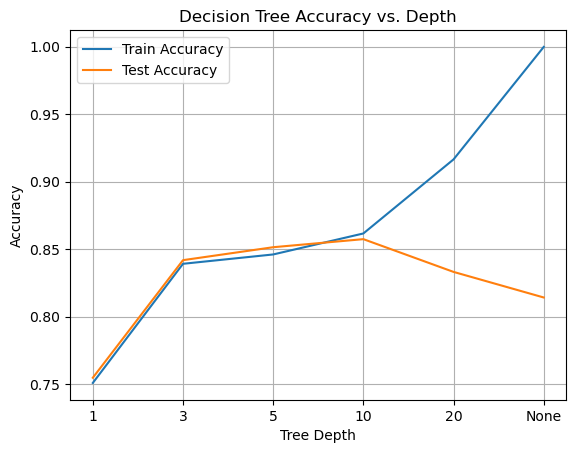

In [170]:
from sklearn.tree import DecisionTreeClassifier


depths = [1, 3, 5, 10, 20, "None"]
train_scores = []
test_scores = []

for depth in depths:
    if depth == "None":
        depth = None
    
    
    '''
     replace with your code here
    '''
    
    train_scores.append(dt.score(X_train_processed, y_train))
    test_scores.append(dt.score(X_test_processed, y_test))

# Plot
plt.plot(depths, train_scores, label='Train Accuracy')
plt.plot(depths, test_scores, label='Test Accuracy')
plt.xlabel('Tree Depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree Accuracy vs. Depth')
plt.legend()
plt.grid()
plt.show()

✅ Task for students: how to further reduce overfitting during training? which option you can change? do this in a similar loop as above.

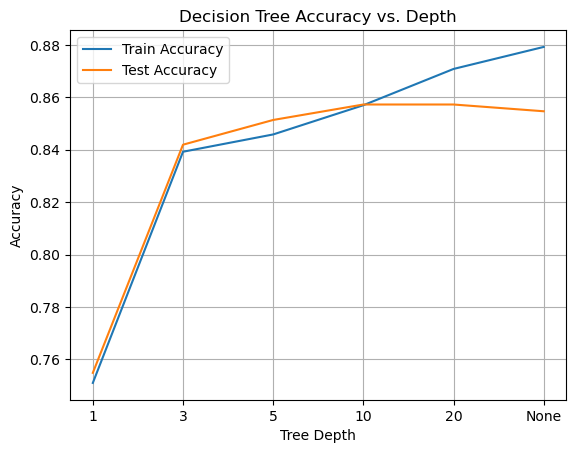

In [173]:
# you can reduce the overfitting during the training by setting min_samples_split to a greater number than the default one for example 100
depths = [1, 3, 5, 10, 20, "None"]
train_scores = []
test_scores = []

for depth in depths:
    if depth == "None":
        depth = None

    '''
     replace with your code here
    '''
    
    train_scores.append(dt.score(X_train_processed, y_train))
    test_scores.append(dt.score(X_test_processed, y_test))

# Plot
plt.plot(depths, train_scores, label='Train Accuracy')
plt.plot(depths, test_scores, label='Test Accuracy')
plt.xlabel('Tree Depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree Accuracy vs. Depth')
plt.legend()
plt.grid()
plt.show()

### 6. Model with random forest classifier

✅ Task for students:
- use sklearn RF classifier
- set the trees number in the forest to 10
- in for loop, create and fit 5 different models, each for one of the following depths[1, 3, 5, 10, 20, "None"] each RF model will have 10 trees
- make sure to convert the string "None" into real None in the loop
- set the  min_samples_split to 100 or 50 
- plot the test and train mean accurancy score for each of the models
- Compare the random forest performance to the best decision tree. Is it overfitting less? Why?

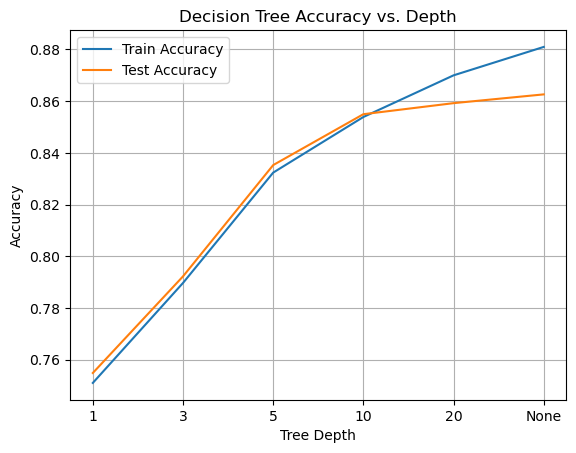

In [174]:
depths = [1, 3, 5, 10, 20, "None"]
train_scores = []
test_scores = []

for depth in depths:
    if depth == "None":
        depth = None

    '''
     replace with your code here
    '''
        
    train_scores.append(rf.score(X_train_processed, y_train))
    test_scores.append(rf.score(X_test_processed, y_test))

# Plot
plt.plot(depths, train_scores, label='Train Accuracy')
plt.plot(depths, test_scores, label='Test Accuracy')
plt.xlabel('Tree Depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree Accuracy vs. Depth')
plt.legend()
plt.grid()
plt.show()

- set the trees number in the forest to 100
- in for loop, create and fit 5 different models, each for one of the following depths[1, 3, 5, 10, 20] each models will have 100 trees
- plot the test and train mean accurancy score for each of the models
- set the  min_samples_split to 100 or 50
- Compare the random forest performance to the best decision tree. Is it overfitting less? Why?
- What happenend when you increased the number of estimators in the forest?

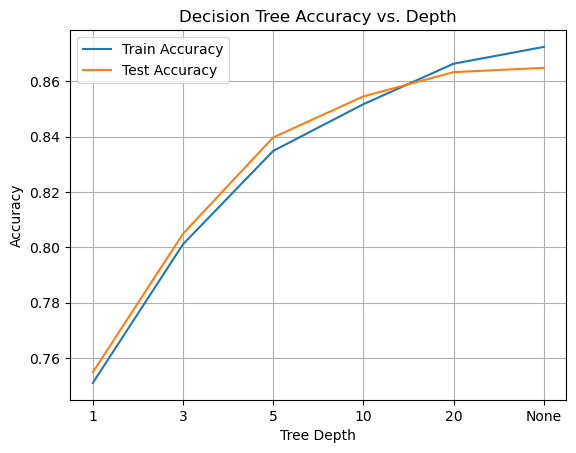

In [175]:
depths = [1, 3, 5, 10, 20, "None"]
train_scores = []
test_scores = []

for depth in depths:
    if depth == "None":
        depth = None

    '''
     replace with your code here
    '''
        
    train_scores.append(rf.score(X_train_processed, y_train))
    test_scores.append(rf.score(X_test_processed, y_test))

# Plot
plt.plot(depths, train_scores, label='Train Accuracy')
plt.plot(depths, test_scores, label='Test Accuracy')
plt.xlabel('Tree Depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree Accuracy vs. Depth')
plt.legend()
plt.grid()
plt.show()

### 7. Questions for Exploration
✅ Task for students:
- How does performance change if you don’t limit max_depth?
- Try max_features='sqrt' or 'log2' in the forest — what changes?

### 9. train a final model and evaluate the performance
✅ Task for students:
- train a final RF model with n_estimators=100, max_depth=None, min_samples_split=100, random_state=random_state)
- print confusion matrix and classificaiton report


In [178]:
# Train final Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=None, 
                            min_samples_split=100, random_state=random_state)

rf.fit(X_train_processed, y_train)

RandomForestClassifier(min_samples_split=100, random_state=42)

In [1]:
# print confusion matrix and classificaiton report

# your code here

### 10. feature importance
- Retrieve and plot feature importances from the trained Random Forest.
- Are you surprised? Could this guide future feature engineering?

Tip: To get feature importances: rf.feature_importances_ (requires mapping back through the processor as it encoded and processed the features)

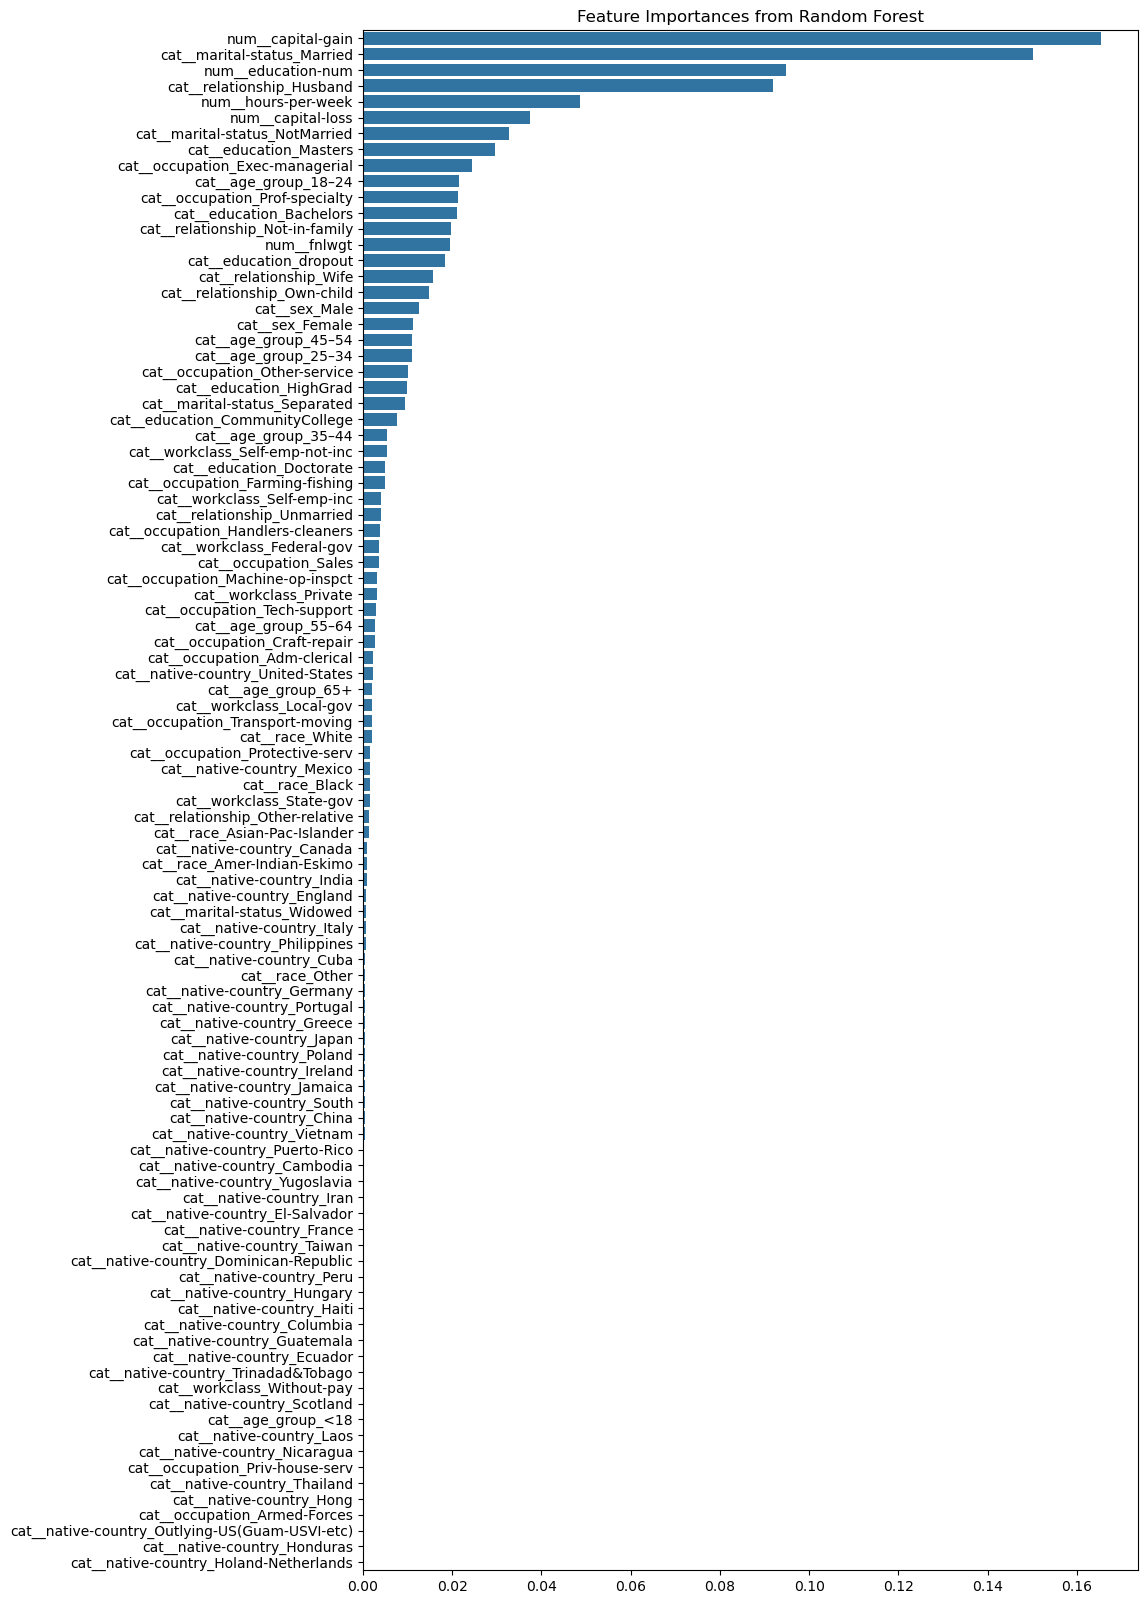

In [180]:
# Get feature names after transformation
feature_names = preprocessor.get_feature_names_out()

# Fix the plotting
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 20))
sns.barplot(x=importances[indices], y=np.array(feature_names)[indices])
plt.title('Feature Importances from Random Forest')
plt.show()
